# 🛡️ NovaPay · EDA
### Synthetic Financial Transaction Data — Fraud Detection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df = pd.read_csv("../data/synthetic_data_RAW.csv")

In [14]:
df.shape

(6362620, 11)

In [15]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [16]:
legit = df[df["isFraud"] == 0].sample(n = 265000, random_state = 42)
fraud = df[df["isFraud"] == 1]

In [17]:
df_balanced = pd.concat([legit, fraud]).reset_index(drop = True)

In [18]:
df_balanced["isFraud"].value_counts()

isFraud
0    265000
1      8213
Name: count, dtype: int64

In [19]:
df_balanced.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,0
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,0
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,0
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,0
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,0


In [20]:
df_balanced = df_balanced.drop(columns = "isFlaggedFraud")

In [21]:
df_balanced["hour_of_the_day"] = df_balanced["step"] % 24

In [22]:
df_balanced.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,18
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,17
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,11
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,19
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,18


In [23]:
high_risk_countries = ['KH', 'CN', 'VE', 'CI', 'NG']
low_risk_countries = ['ES', 'US', 'DE', 'FR', 'GB']

df_balanced['ip_country'] = df_balanced['isFraud'].apply(
    lambda x: np.random.choice(high_risk_countries) 
    if (x == 1 and np.random.random() < 0.6) 
    else np.random.choice(low_risk_countries)
)

In [24]:
high_risk_categories = ['crypto', 'electronics']
low_risk_categories = ['grocery', 'restaurant', 'pharmacy', 'fuel', 'transport']

df_balanced['merchant_category'] = df['isFraud'].apply(
    lambda x: np.random.choice(high_risk_categories)
    if (x == 1 and np.random.random() < 0.65)
    else np.random.choice(low_risk_categories)
)

In [25]:
df_balanced.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category
0,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,18,FR,transport
1,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,17,FR,fuel
2,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,11,DE,electronics
3,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,19,DE,crypto
4,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,18,ES,fuel


## 📊 Visual EDA
### Distribution, patterns and fraud signals across key features

In [27]:
df_balanced.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'hour_of_the_day',
 'ip_country',
 'merchant_category']

### 1. Class Distribution — Legit vs Fraud

The dataset is heavily imbalanced: **265,000 legitimate transactions** vs only **8,213 fraudulent ones** — 
a fraud rate of approximately **3%**. This mirrors real-world payment fraud ratios and means our model 
must be explicitly trained to handle class imbalance, using techniques such as `class_weight = 'balanced'` 
in Random Forest and `scale_pos_weight` in XGBoost.

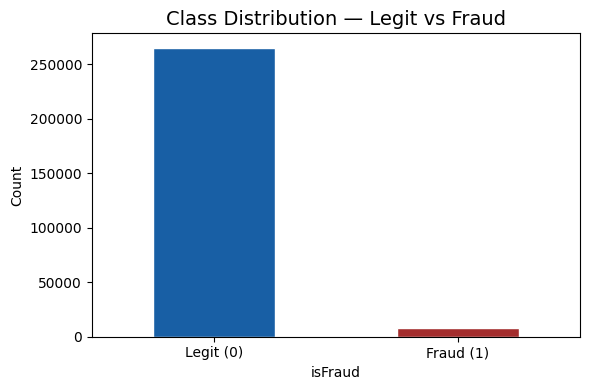

In [ ]:
ax = df_balanced["isFraud"].value_counts().plot(
    kind = "bar", color = ["#185FA5", "#A32D2D"],
    figsize = (6,4), edgecolor = "white"
)
ax.set_title("Class Distribution — Legit vs Fraud", fontsize = 14)
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation = 0)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 2. Fraud Rate by Transaction Type

Fraud is almost exclusively concentrated in two transaction types: **TRANSFER** (~16% fraud rate) 
and **CASH_OUT** (~4% fraud rate). **CASH_IN, DEBIT and PAYMENT show zero fraudulent activity** 
in this dataset. This is a critical finding — `type` will likely be one of the strongest predictors 
in our model, and any transaction flagged as TRANSFER should immediately be treated as higher risk.

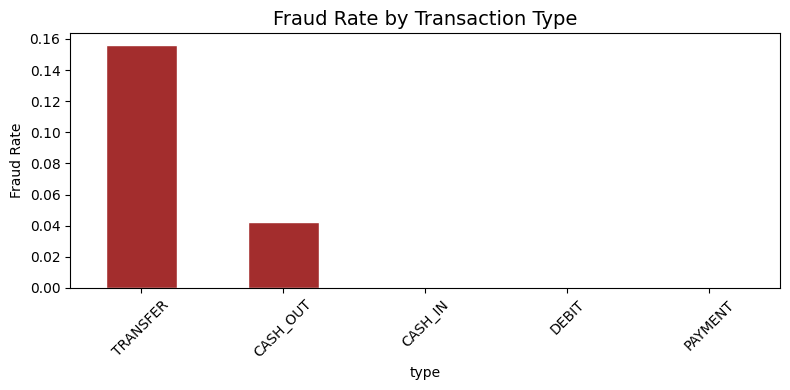

In [ ]:
fraud_by_type = df_balanced.groupby("type")["isFraud"].mean().sort_values(ascending=False)

ax = fraud_by_type.plot(
    kind = "bar", color = "#A32D2D", figsize = (8,4), edgecolor = "white"
)
ax.set_title("Fraud Rate by Transaction Type", fontsize = 14)
ax.set_ylabel("Fraud Rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
plt.tight_layout()
plt.show()

### 3. Transaction Amount Distribution — Legit vs Fraud

The two distributions tell very different stories. **Legitimate transactions** are heavily concentrated 
at low amounts, with the vast majority below €100,000 and a long tail towards higher values. 
**Fraudulent transactions** however show a striking spike at the €500,000 cap, revealing that fraud 
in this dataset is systematically associated with **very high-value transactions**. This makes `amount` 
one of the most powerful features for our model — a transaction approaching the upper limit should 
immediately raise the fraud risk score.

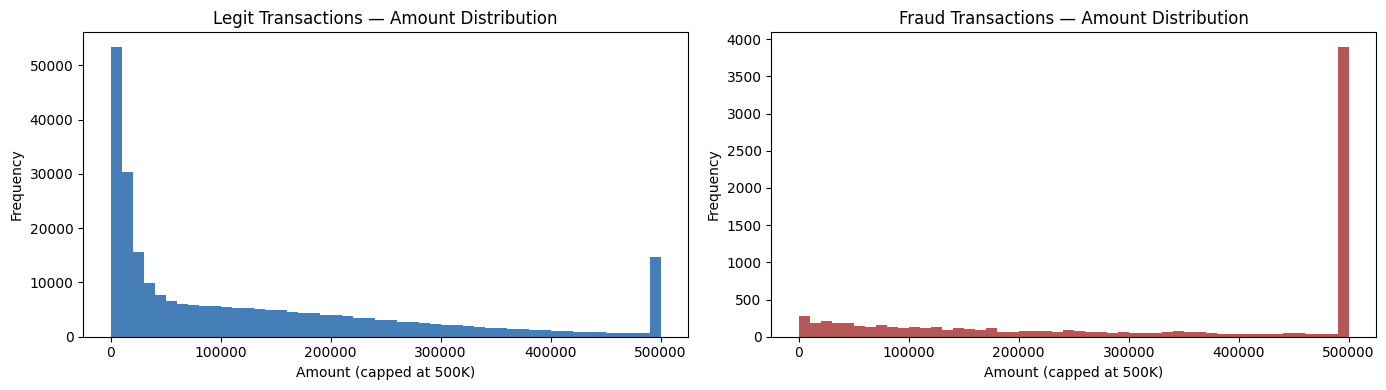

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_balanced[df_balanced["isFraud"] == 0]["amount"].clip(upper = 500000).plot(
    kind = "hist", bins = 50, alpha = 0.8, color = "#185FA5", ax = axes[0]
)
axes[0].set_title("Legit Transactions — Amount Distribution")
axes[0].set_xlabel("Amount (capped at 500K)")

df_balanced[df_balanced["isFraud"] == 1]["amount"].clip(upper = 500000).plot(
    kind = "hist", bins = 50, alpha = 0.8, color = "#A32D2D", ax = axes[1]
)
axes[1].set_title("Fraud Transactions — Amount Distribution")
axes[1].set_xlabel("Amount (capped at 500K)")

plt.tight_layout()
plt.show()

### 4. Fraud Rate by Hour of Day

This is one of the most compelling findings in the EDA. **Between 3am and 5am, over 80% of all 
transactions are fraudulent** — peaking at approximately 87% at hour 4. From 9am onwards, the fraud 
rate drops to near zero and remains flat throughout business hours. This pattern is consistent with 
real-world fraud behaviour: attackers operate during off-peak hours when monitoring is reduced and 
victims are unlikely to notice suspicious activity on their accounts. `hour_of_the_day` is therefore 
a high-value engineered feature that our model should leverage heavily.

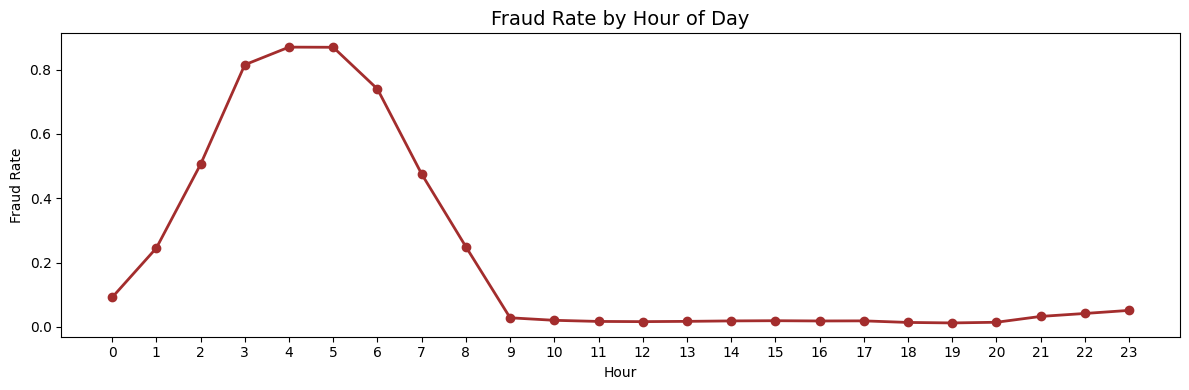

In [ ]:
fraud_by_hour = df_balanced.groupby("hour_of_the_day")["isFraud"].mean()

ax = fraud_by_hour.plot(
    kind = "line", figsize = (12, 4), color = "#A32D2D", linewidth = 2, marker = "o"
)
ax.set_title("Fraud Rate by Hour of Day", fontsize = 14)
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud Rate")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 5. Fraud Rate by Merchant Category

The `merchant_category` column shows **no meaningful signal** for fraud detection. All active 
categories (fuel, pharmacy, grocery, transport, restaurant) display an identical fraud rate of 
approximately **3%** — which is simply the global fraud rate of the dataset. Meanwhile, crypto 
and electronics show zero fraud entirely. This reveals that `merchant_category` was assigned 
independently of the fraud label during data generation, meaning it carries **no predictive power** 
in its current form. This will be addressed in Round 2, where Red Team will deliberately link 
high-risk merchant categories to fraudulent transactions to create a genuine signal.

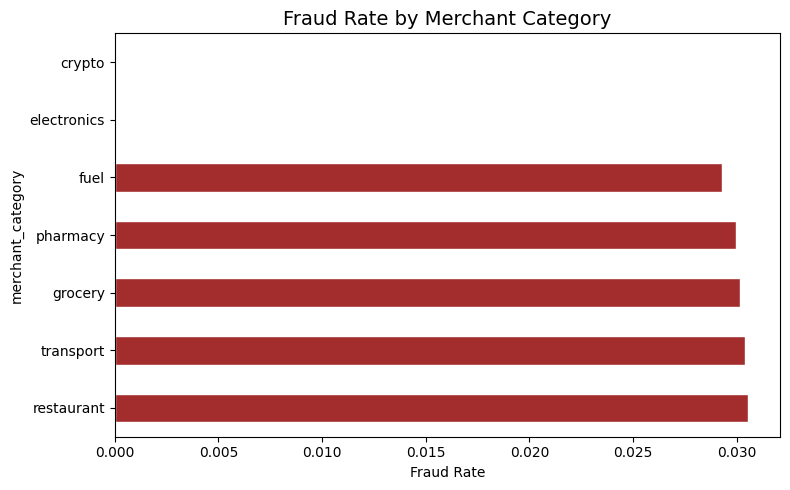

In [ ]:
fraud_by_merchant = df_balanced.groupby("merchant_category")["isFraud"].mean().sort_values(ascending = False)

ax = fraud_by_merchant.plot(
    kind = "barh", color = "#A32D2D", figsize = (8, 5), edgecolor = "white"
)
ax.set_title("Fraud Rate by Merchant Category", fontsize = 14)
ax.set_xlabel("Fraud Rate")
plt.tight_layout()
plt.show()

⚠️ merchant_category shows no meaningful correlation with isFraud — 
this column was synthetically added and not linked to fraud logic. 
To be addressed in Round 2 data generation.

### 6. Correlation Heatmap

The heatmap confirms and quantifies the signals identified in previous plots. The strongest 
correlations with `isFraud` are:

- **`amount` (0.29)** — higher transaction amounts are positively correlated with fraud, 
consistent with what we observed in the amount distribution plot
- **`hour_of_the_day` (-0.14)** — negative correlation meaning fraud concentrates at 
lower hour values (early morning), confirming the 3am-5am spike
- **`step` (0.15)** — weak positive correlation with time progression in the simulation

Two additional patterns worth noting: `oldbalanceOrg` and `newbalanceOrig` are almost perfectly 
correlated **(0.99)** — meaning they carry near-identical information and one could be dropped 
to reduce redundancy. Similarly, `oldbalanceDest` and `newbalanceDest` show a **(0.98)** 
correlation. Notably, `ip_country` and `merchant_category` show **zero correlation with fraud** 
(0.01 and 0.00), reinforcing our earlier finding that these synthetic columns carry no predictive 
signal in Round 1.

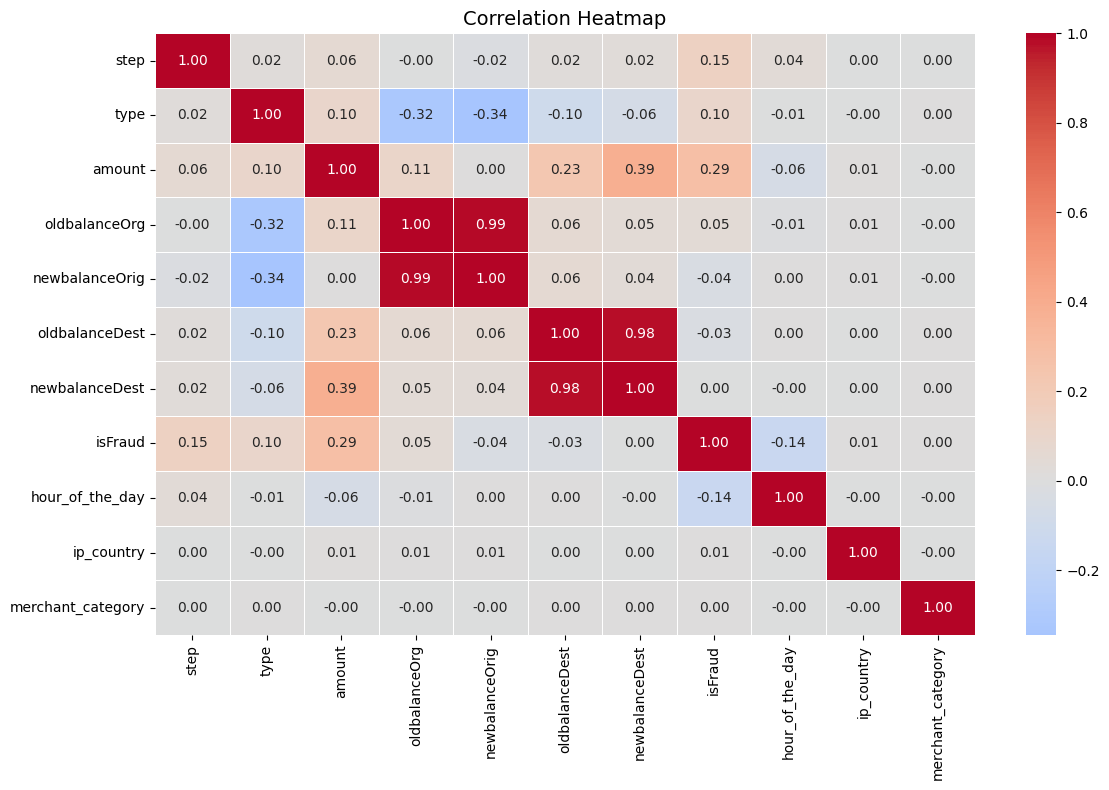

In [39]:
# CORRELATION MAP 

le = LabelEncoder()

df_encoded = df_balanced.copy()
for col in ["type", "ip_country", "merchant_category"]:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded = df_encoded.drop(columns=["nameOrig", "nameDest"])

plt.figure(figsize = (12,8))
sns.heatmap(
    df_encoded.corr(),
    annot = True, fmt = ".2f",
    cmap = "coolwarm", center = 0,
    linewidths = 0.5
)
plt.title("Correlation Heatmap", fontsize = 14)
plt.tight_layout()
plt.show()

### 7. Balance Discrepancy — Legit vs Fraud

The `balance_discrepancy` feature (`oldbalanceOrg - amount - newbalanceOrig`) reveals two distinct 
patterns. **Legitimate transactions** split into two clusters: one at **-50,000** (transactions where 
the sender's balance dropped more than expected — likely large transfers) and one at **0** (perfectly 
balanced books). **Fraudulent transactions** concentrate almost entirely at **0**, suggesting that 
fraudsters are draining accounts completely, leaving the balance floored at zero rather than going 
negative. This engineered feature captures a behavioural pattern that raw balance columns alone would 
miss, and is a direct product of domain knowledge from the financial services industry.

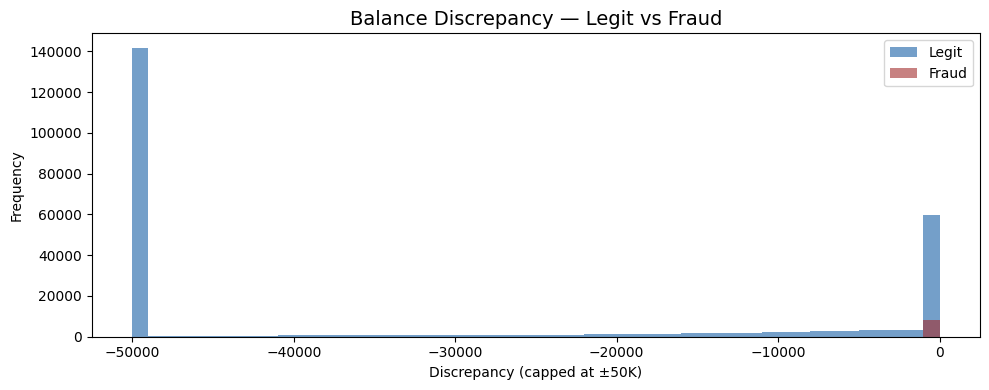

In [ ]:
df_balanced["balance_discrepancy"] = df_balanced["oldbalanceOrg"] - df_balanced["amount"] - df_balanced["newbalanceOrig"]

fig, ax = plt.subplots(figsize = (10,4))
df_balanced[df_balanced["isFraud"] == 0]["balance_discrepancy"].clip(-50000, 50000).plot(
    kind = "hist", bins = 50, alpha = 0.6, color = "#185FA5", label = "Legit", ax = ax
)
df_balanced[df_balanced["isFraud"] == 1]["balance_discrepancy"].clip(-50000, 50000).plot(
    kind = "hist", bins = 50, alpha = 0.6, color = "#A32D2D", label = "Fraud", ax = ax
)
ax.set_title("Balance Discrepancy — Legit vs Fraud", fontsize = 14)
ax.set_xlabel("Discrepancy (capped at ±50K)")
ax.legend()
plt.tight_layout()
plt.show()

## 🔄 Round 2 — Key Takeaways & Recommendations

Based on the EDA findings, the following insights should guide both Red Team's fraud redesign 
and Blue Team's modelling improvements heading into Round 2.

---

### 🔴 Red Team — What to change

- **Exploit the hour window** — fraud is currently concentrated between 3am-5am, making it 
trivially detectable. In Round 2, distribute fraud transactions across business hours to blend 
in with legitimate activity.

- **Diversify transaction types** — fraud is exclusively found in TRANSFER and CASH_OUT. 
Introducing fraud in PAYMENT or DEBIT transactions will break one of Blue Team's strongest signals.

- **Link merchant category to fraud** — crypto and electronics currently show zero fraud. 
Deliberately assigning high-risk merchant categories to fraudulent transactions will create 
a new signal for Blue Team to discover — and a new evasion vector to exploit.

- **Moderate transaction amounts** — the extreme spike at €500K is an obvious tell. 
Round 2 fraud should use amounts that fall within the legitimate distribution range to avoid 
easy detection by amount thresholds.

- **Fix balance discrepancies** — fraudulent transactions currently leave a clear zero-balance 
signature. Simulate more realistic post-fraud balance states to obscure this engineered feature.

---

### 🔵 Blue Team — What to improve

- **Drop redundant features** — `oldbalanceOrg` / `newbalanceOrig` (0.99 correlation) and 
`oldbalanceDest` / `newbalanceDest` (0.98 correlation) are near-identical pairs. 
Drop one from each pair to reduce noise and improve model efficiency.

- **Upgrade merchant category and ip_country** — these showed zero predictive power in Round 1. 
Once Red Team links them to fraud in Round 2, revisit their encoding and feature importance.

- **Add velocity features** — transaction count per user in the last hour/day to catch 
rapid-fire fraud patterns that individual transaction features miss.

- **Tune the decision threshold** — the default 0.5 threshold may not be optimal for this 
class imbalance. Experiment with lower thresholds to prioritise recall over precision.

- **Try XGBoost** — compare its Round 2 performance against Random Forest and document 
the delta in F1 score as evidence of model improvement.

In [26]:
# df_balanced.to_csv("C:/Users/Usuario/Desktop/the bridge/github/Desafio_Grupo1/data/synthetic_fin_data_CLEAN.csv", index = False)